In [432]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [433]:
import warnings

# Suppress all FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [434]:
df=pd.read_csv(r'https://raw.githubusercontent.com/cmrivers/ebola/master/country_timeseries.csv')

# Visualize the Data Set structure

### Before proceeding with analysis, we conduct a comprehensive assessment of the dataset's core characteristics to establish data quality and identify potential issues.

In [435]:
df.shape

(122, 18)

In [436]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    object 
 1   Day                  122 non-null    int64  
 2   Cases_Guinea         93 non-null     float64
 3   Cases_Liberia        83 non-null     float64
 4   Cases_SierraLeone    87 non-null     float64
 5   Cases_Nigeria        38 non-null     float64
 6   Cases_Senegal        25 non-null     float64
 7   Cases_UnitedStates   18 non-null     float64
 8   Cases_Spain          16 non-null     float64
 9   Cases_Mali           12 non-null     float64
 10  Deaths_Guinea        92 non-null     float64
 11  Deaths_Liberia       81 non-null     float64
 12  Deaths_SierraLeone   87 non-null     float64
 13  Deaths_Nigeria       38 non-null     float64
 14  Deaths_Senegal       22 non-null     float64
 15  Deaths_UnitedStates  18 non-null     flo

Date                     0
Day                      0
Cases_Guinea            29
Cases_Liberia           39
Cases_SierraLeone       35
Cases_Nigeria           84
Cases_Senegal           97
Cases_UnitedStates     104
Cases_Spain            106
Cases_Mali             110
Deaths_Guinea           30
Deaths_Liberia          41
Deaths_SierraLeone      35
Deaths_Nigeria          84
Deaths_Senegal         100
Deaths_UnitedStates    104
Deaths_Spain           106
Deaths_Mali            110
dtype: int64


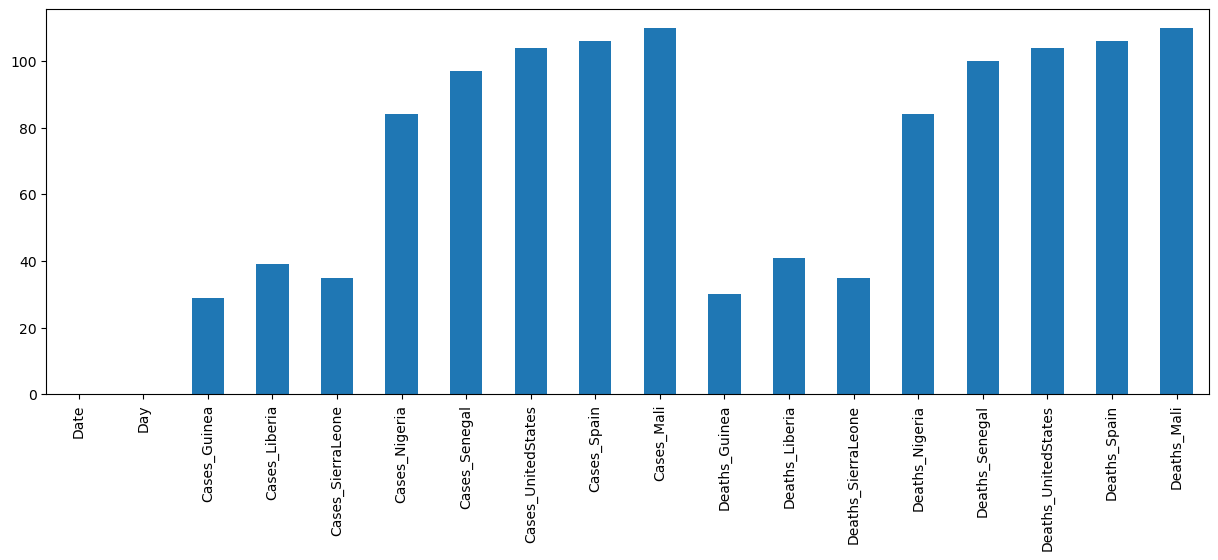

In [437]:
plt.figure(figsize=(15,5))
df.isnull().sum().plot(kind='bar')
print(df.isnull().sum());

Summary of diagnosis of the dataset

In [438]:
def data_diagnostic(df, name="Dataset"):
    """Comprehensive data quality assessment"""
    print(f"📊 {name} DIAGNOSTIC REPORT")
    print("=" * 50)
    
    # 1. Basic Dimensions
    print(f"1. SHAPE: {df.shape[0]} rows × {df.shape[1]} columns")
    
    # 2. Data Types Breakdown
    print(f"\n2. DATA TYPES:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"   - {dtype}: {count} columns")
    
    # 3. Memory Usage
    mem_usage = df.memory_usage(deep=True).sum() / 1024**2
    print(f"\n3. MEMORY USAGE: {mem_usage:.2f} MB")
    
    # 4. Missing Values
    total_cells = df.size
    missing_cells = df.isnull().sum().sum()
    missing_pct = (missing_cells / total_cells) * 100
    
    print(f"\n4. MISSING VALUES: {missing_cells:,} / {total_cells:,} cells ({missing_pct:.1f}%)")
    
    if missing_cells > 0:
        print("\n   Columns with Missing Values (>0%):")
        null_series = df.isnull().sum()
        for col in null_series[null_series > 0].index:
            col_missing = null_series[col]
            col_pct = (col_missing / len(df)) * 100
            print(f"   - {col}: {col_missing:,} ({col_pct:.1f}%)")
    
    # 5. Duplicate Rows
    duplicates = df.duplicated().sum()
    print(f"\n5. DUPLICATE ROWS: {duplicates:,} ({duplicates/len(df)*100:.1f}%)")
    
    # 6. Sample Data Preview
    print(f"\n6. DATA PREVIEW:")
    print(df.head())
    
    return {
        'shape': df.shape,
        'memory_mb': mem_usage,
        'missing_cells': missing_cells,
        'missing_pct': missing_pct,
        'duplicates': duplicates
    }

# Execute diagnostic
diagnostic_results = data_diagnostic(df, "Ebola Cases Dataset")

 Ebola Cases Dataset DIAGNOSTIC REPORT
1. SHAPE: 122 rows × 18 columns

2. DATA TYPES:
   - float64: 16 columns
   - object: 1 columns
   - int64: 1 columns

3. MEMORY USAGE: 0.02 MB

4. MISSING VALUES: 1,214 / 2,196 cells (55.3%)

   Columns with Missing Values (>0%):
   - Cases_Guinea: 29 (23.8%)
   - Cases_Liberia: 39 (32.0%)
   - Cases_SierraLeone: 35 (28.7%)
   - Cases_Nigeria: 84 (68.9%)
   - Cases_Senegal: 97 (79.5%)
   - Cases_UnitedStates: 104 (85.2%)
   - Cases_Spain: 106 (86.9%)
   - Cases_Mali: 110 (90.2%)
   - Deaths_Guinea: 30 (24.6%)
   - Deaths_Liberia: 41 (33.6%)
   - Deaths_SierraLeone: 35 (28.7%)
   - Deaths_Nigeria: 84 (68.9%)
   - Deaths_Senegal: 100 (82.0%)
   - Deaths_UnitedStates: 104 (85.2%)
   - Deaths_Spain: 106 (86.9%)
   - Deaths_Mali: 110 (90.2%)

5. DUPLICATE ROWS: 0 (0.0%)

6. DATA PREVIEW:
         Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone  \
0    1/5/2015  289        2776.0            NaN            10030.0   
1    1/4/2015  288        

# Explaination of Dataset

 - Date represent the date the measures have been taken for Cases and Deaths
 - Day represent the day since beginning of Pandemic

In [439]:
df.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
0,1/5/2015,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN
1,1/4/2015,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN
2,1/3/2015,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN
3,1/2/2015,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN
4,12/31/2014,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN


### The initial data structure follows a wide format, where each row represents multiple time periods. To enhance analytical capabilities, particularly for time-series examination, country-specific trend analysis, and interactive visualization, we will restructure the dataset into a long format. This approach aligns with tidy data principles and improves compatibility with statistical modeling and visualization libraries.

In [440]:
cases = df.melt(
    id_vars=['Date','Day'],
    value_vars=[col for col in df.columns if col.startswith("Cases_")],
    var_name = 'Country',
    value_name = 'Cases'
)

In [441]:
deaths = df.melt(
    id_vars = ['Date','Day'],
    value_vars=[col for col in df.columns if col.startswith("Deaths_")],
    var_name='Country',
    value_name='Deaths'
)

In [443]:
cases['Country'] = cases['Country'].str.replace('Cases_','')
deaths['Country'] = deaths['Country'].str.replace('Deaths_','')

In [444]:
df1=cases.merge(deaths,on=['Date','Day','Country'], how = 'outer')

In [445]:
df1

,Date,Day,Country,Cases,Deaths
0,1/2/2015,286,Guinea,NaN,NaN
1,1/2/2015,286,Liberia,8157.0,3496.0
2,1/2/2015,286,Mali,NaN,NaN
3,1/2/2015,286,Nigeria,NaN,NaN
4,1/2/2015,286,Senegal,NaN,NaN
...,...,...,...,...,...
971,9/9/2014,171,Nigeria,NaN,NaN
972,9/9/2014,171,Senegal,NaN,NaN
973,9/9/2014,171,SierraLeone,NaN,NaN
974,9/9/2014,171,Spain,NaN,NaN


# Dealing with null

In [446]:
df1[df1.isnull().any(axis=1)]

,Date,Day,Country,Cases,Deaths
0,1/2/2015,286,Guinea,NaN,NaN
2,1/2/2015,286,Mali,NaN,NaN
3,1/2/2015,286,Nigeria,NaN,NaN
4,1/2/2015,286,Senegal,NaN,NaN
5,1/2/2015,286,SierraLeone,NaN,NaN
...,...,...,...,...,...
971,9/9/2014,171,Nigeria,NaN,NaN
972,9/9/2014,171,Senegal,NaN,NaN
973,9/9/2014,171,SierraLeone,NaN,NaN
974,9/9/2014,171,Spain,NaN,NaN


# Fill Nan with 0 
- We decided a Nan Value can Indicate absence of cases and deaths on that specific days.

In [447]:
df1 = df1.fillna(0)

# Mining the datetimes  
- Change format 
- Add week and month

In [448]:
import datetime as dt

In [449]:
df1['Date']=pd.to_datetime(df1['Date'],format='%m/%d/%Y',dayfirst=True)

In [450]:
df1['Year'] = df1['Date'].dt.year
df1['month'] = df1['Date'].dt.month
df1['week'] = df1['Date'].dt.isocalendar().week

### We now have also month and week values

In [451]:
df1

,Date,Day,Country,Cases,Deaths,Year,month,week
0,2015-01-02,286,Guinea,0.0,0.0,2015,1,1
1,2015-01-02,286,Liberia,8157.0,3496.0,2015,1,1
2,2015-01-02,286,Mali,0.0,0.0,2015,1,1
3,2015-01-02,286,Nigeria,0.0,0.0,2015,1,1
4,2015-01-02,286,Senegal,0.0,0.0,2015,1,1
...,...,...,...,...,...,...,...,...
971,2014-09-09,171,Nigeria,0.0,0.0,2014,9,37
972,2014-09-09,171,Senegal,0.0,0.0,2014,9,37
973,2014-09-09,171,SierraLeone,0.0,0.0,2014,9,37
974,2014-09-09,171,Spain,0.0,0.0,2014,9,37


# Cases and Death over the time

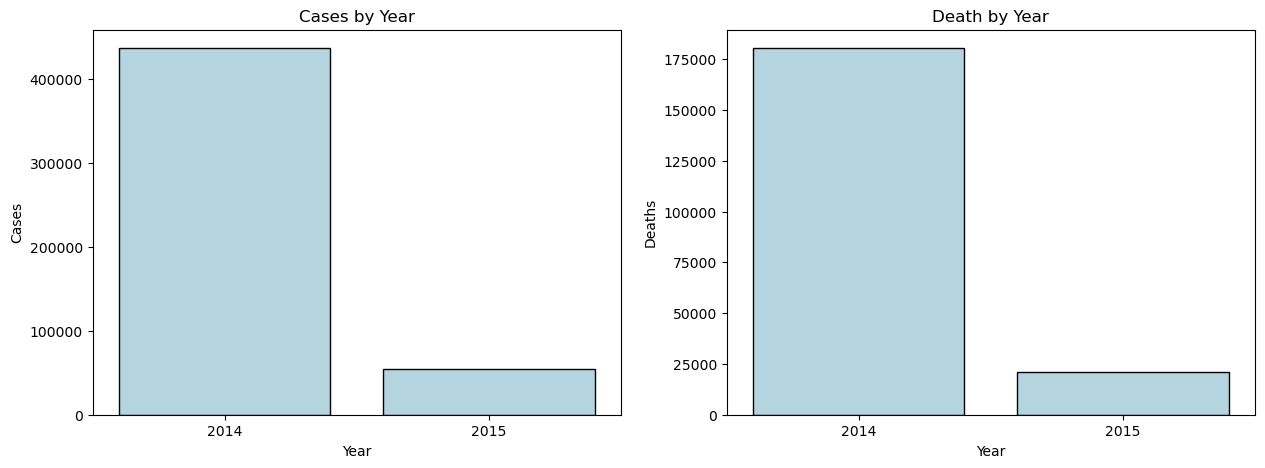

In [452]:
fig,axis=plt.subplots(1,2,figsize=(15,5))
sns.barplot(x=df1.groupby('Year')['Cases'].sum().reset_index()['Year'],y=df1.groupby('Year')['Cases'].sum().reset_index()['Cases'],color='lightblue',edgecolor='black',errorbar=None,ax=axis[0])
axis[0].set_title('Cases by Year');
sns.barplot(x=df1.groupby('Year')['Deaths'].sum().reset_index()['Year'],y=df1.groupby('Year')['Deaths'].sum().reset_index()['Deaths'],color='lightblue',edgecolor='black',errorbar=None,ax=axis[1])
axis[1].set_title('Death by Year');

### The bar charts comparing total Ebola cases and deaths by year need to be interpreted with caution because the dataset is heavily unbalanced, with substantially more observations recorded for 2014 than for 2015. As a result, the global totals shown in the bar plots naturally appear higher for 2014 simply because the year contains more weeks of data rather than reflecting a genuine epidemiological decline. This imbalance means that yearly totals are not directly comparable. However, when looking at weekly or cumulative trends, the data still indicates that the outbreak was intensifying toward the end of 2014 and into early 2015. Therefore, while the bar charts reflect dataset imbalance rather than true yearly differences, the underlying weekly progression confirms that cases and deaths were continuing to rise as the epidemic moved into 2015.

In [453]:
df1=df1.sort_values(by=['Country','Date']) # Sort df first by country then date for preparing the data for correct cumsum
df1['cumsum'] = df1.groupby('Country')['Cases'].cumsum()

In [454]:
# we have multiple week values 1 we need to make sure for the correct representation value of week are unique
df1['yearweek'] = df1['Year'].astype(str) + '/' + df1['week'].astype(str) # we create a new week column yearweek

In [455]:
df1['global_cases']=df1['Cases'].cumsum()
df1['global_deaths']=df1['Deaths'].cumsum()

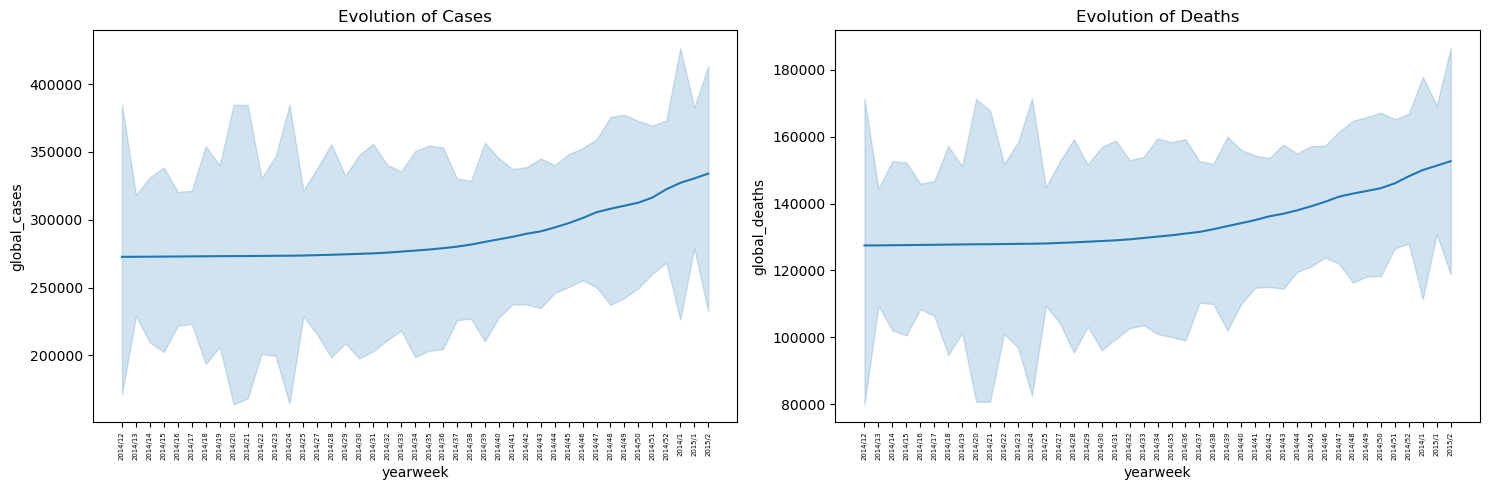

In [456]:
fig,axis=plt.subplots(1,2,figsize=(15,5))

sns.lineplot(x=df1['yearweek'],y=df1['global_cases'],ax=axis[0])
axis[0].set_title('Evolution of Cases')
axis[0].tick_params(axis='x',rotation=90,labelsize=5)

sns.lineplot(x=df1['yearweek'],y=df1['global_deaths'],ax=axis[1])
axis[1].set_title('Evolution of Deaths')
axis[1].tick_params(axis='x',rotation=90,labelsize=5)

plt.tight_layout();

### The cumulative line charts instead show a clear increase in both global cases and global deaths, with the most pronounced growth occurring in 2015. The cumulative curves rise more steeply during this period, indicating that infections and fatalities were accelerating rather than stabilising. This pattern confirms that, despite the dataset’s imbalance across years, the outbreak continued to intensify throughout 2015.

In [457]:
df1['Death_rate'] = df1['Deaths']/df1['Cases']


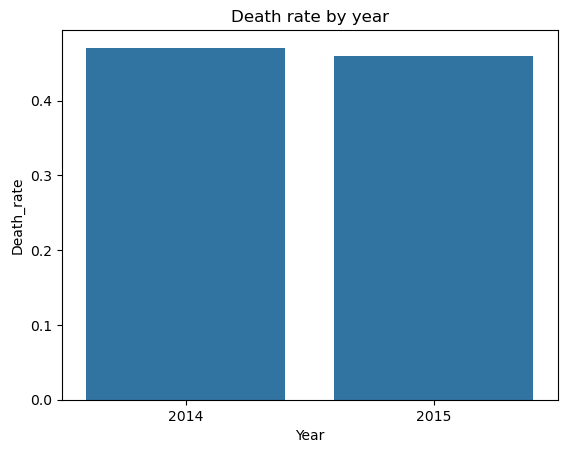

In [461]:
sns.barplot(x=df1[~(df1['Death_rate'] == np.inf)].groupby('Year')['Death_rate'].mean().reset_index()['Year'],y=df1[~(df1['Death_rate'] == np.inf)].groupby('Year')['Death_rate'].mean().reset_index()['Death_rate'])
plt.title('Death rate by year');

### The bar chart reporting the mean death rate by year after removing infinite values caused by weeks with zero reported cases indicates a substantial decrease in death rate in 2015 compared to 2014.

### In 2014, many records include deaths reported on weeks with zero or very low case counts, inflating the weekly death rate and making the average for the year artificially high. Once these distorted values are removed, the 2014 death rate remains noticeably higher than that of 2015.

### By contrast, the 2015 data contains more consistent reporting and fewer zero-case weeks, producing a more stable and realistic death-rate estimate. As a result, the barplot shows a sensible decline in death rate in 2015, suggesting that case management, reporting quality, or outbreak response conditions may have improved relative to 2014.

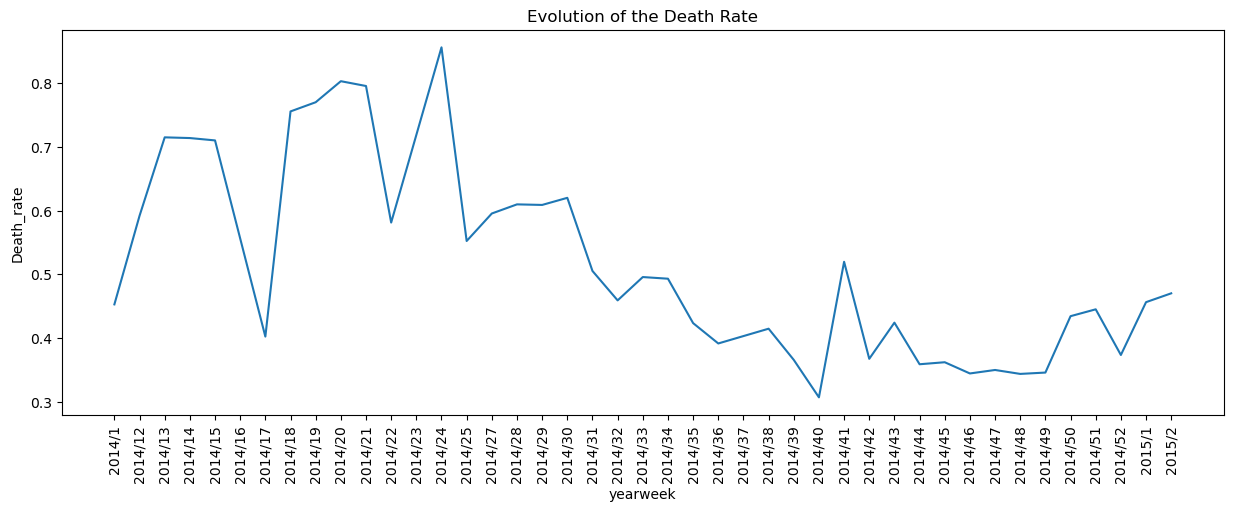

In [463]:
plt.figure(figsize=(15,5))
sns.lineplot(x=df1.groupby('yearweek')['Death_rate'].mean().reset_index()['yearweek'],y=df1.groupby('yearweek')['Death_rate'].mean().reset_index()['Death_rate'])
plt.title('Evolution of the Death Rate')
plt.xticks(rotation=90,fontsize=10);

### The weekly evolution of the death rate highlights how elevated the fatality levels were during the early stages of the outbreak. In the first weeks observed in the dataset, the death rate reaches its highest values, reflecting either very severe early transmission conditions or inconsistent reporting (e.g., deaths recorded before cases were consistently reported).

### As the outbreak progresses, the weekly death rate becomes more stable and generally decreases, aligning with the overall trend seen in the annual averages. This pattern suggests that the epidemiological situation gradually improved, with relatively fewer deaths per reported case as 2015 approached.

In [467]:
df1['cumsum_deaths'] = df1.groupby('Country')['Deaths'].cumsum()

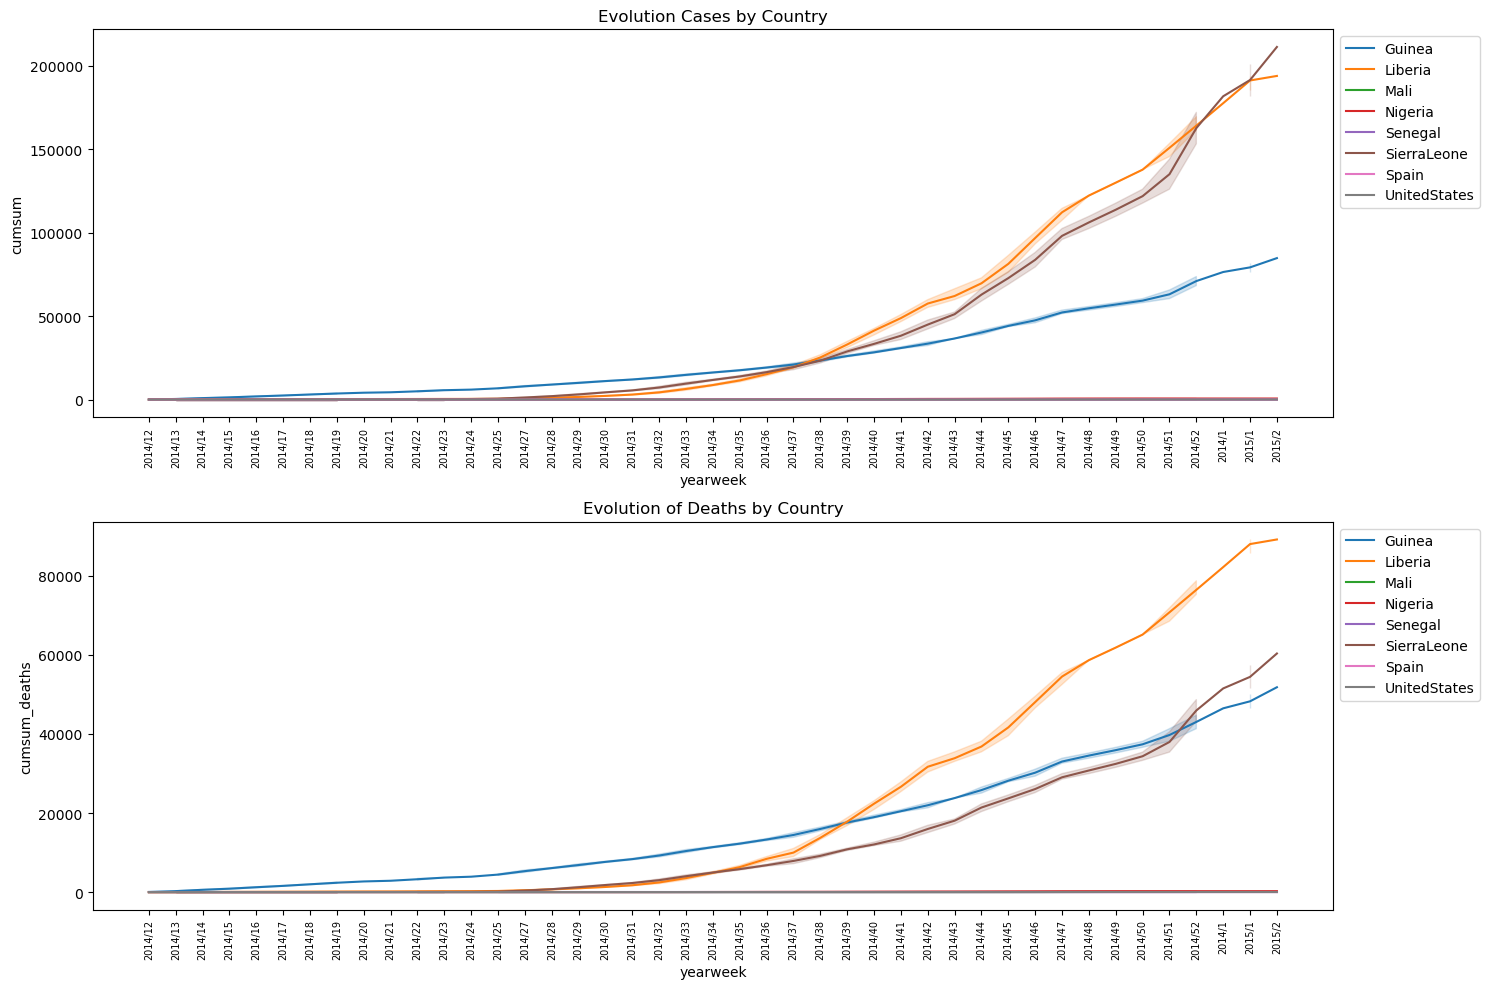

In [470]:
fig, axis = plt.subplots(2, 1, figsize=(15,10))

sns.lineplot(x=df1['yearweek'], y=df1['cumsum'], hue=df1['Country'], ax=axis[0])
axis[0].tick_params(axis='x', rotation=90, labelsize=7)
axis[0].legend(bbox_to_anchor=(1, 1))
axis[0].set_title('Evolution Cases by Country')

sns.lineplot(x=df1['yearweek'],y=df1['cumsum_deaths'],hue=df1['Country'],ax=axis[1])
axis[1].tick_params(axis='x',rotation=90,labelsize=7)
axis[1].legend(bbox_to_anchor=(1,1))
axis[1].set_title('Evolution of Deaths by Country')

plt.tight_layout();

### Although Sierra Leone reported the highest total number of cases, Liberia experienced the highest total number of deaths. This indicates that, despite fewer infections, the outbreak in Liberia was proportionally more fatal, suggesting either differences in healthcare response, reporting practices, or disease severity between the two countries.

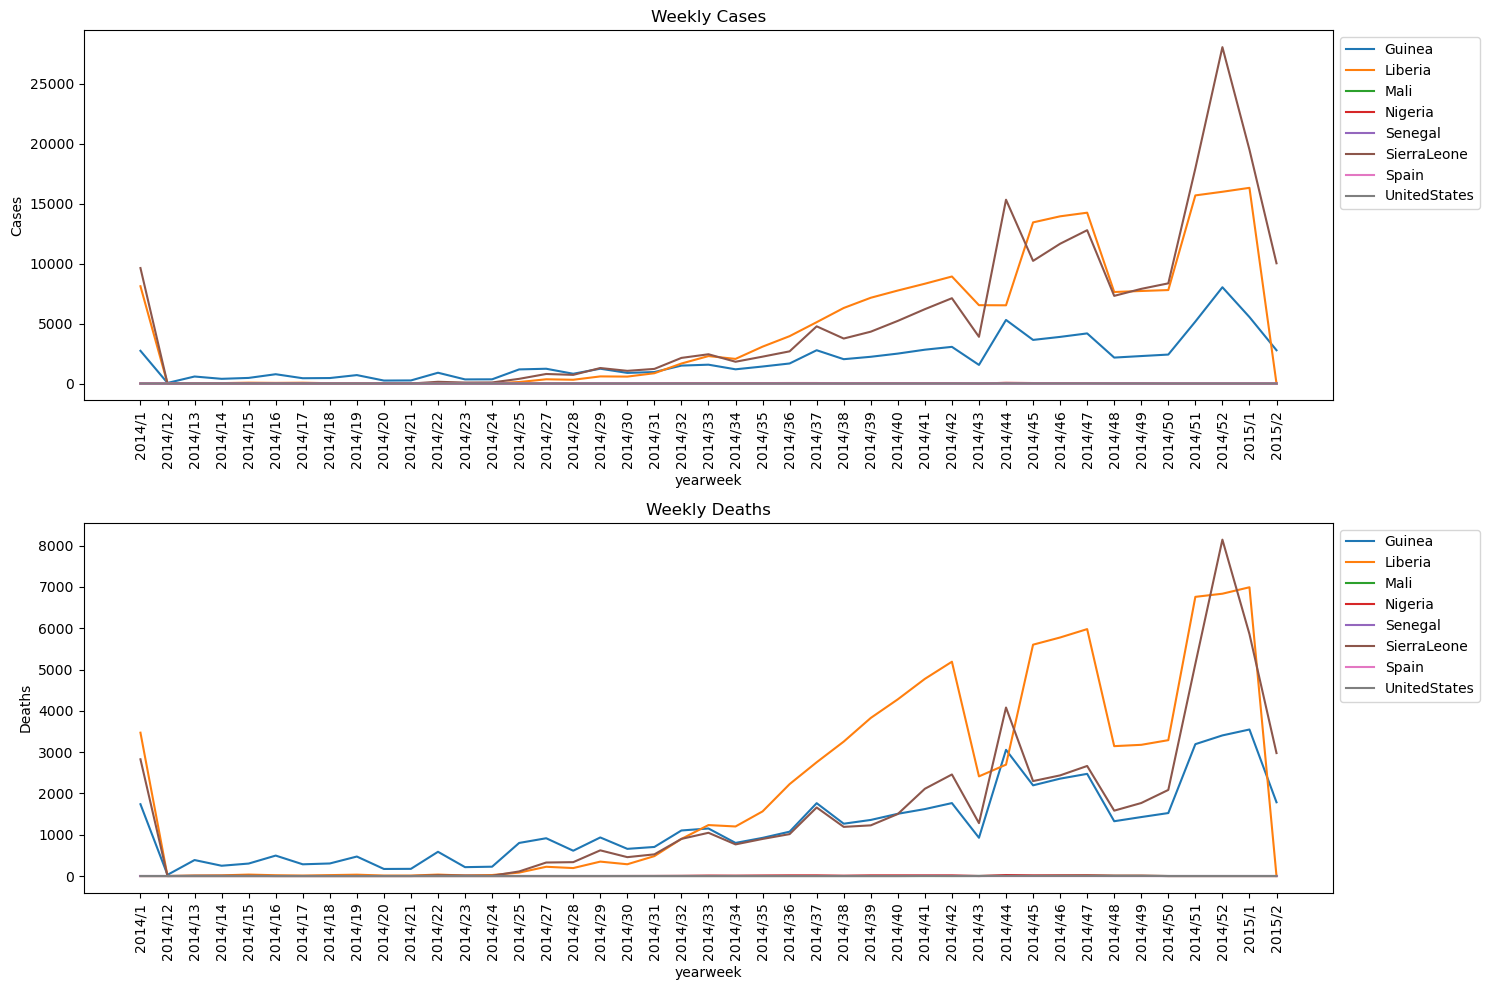

In [477]:
fig,axis=plt.subplots(2,1,figsize=(15,10))

sns.lineplot(x=df1.groupby(['yearweek','Country'])['Cases'].sum().reset_index()['yearweek'],y=df1.groupby(['yearweek','Country'])['Cases'].sum().reset_index()['Cases'],hue=df1.groupby(['yearweek','Country'])['Cases'].sum().reset_index()['Country'],ax=axis[0])
axis[0].tick_params(axis='x',rotation=90)
axis[0].set_title('Weekly Cases')
axis[0].legend(bbox_to_anchor=(1,1,))

sns.lineplot(x=df1.groupby(['yearweek','Country'])['Deaths'].sum().reset_index()['yearweek'],y=df1.groupby(['yearweek','Country'])['Deaths'].sum().reset_index()['Deaths'],hue=df1.groupby(['yearweek','Country'])['Deaths'].sum().reset_index()['Country'],ax=axis[1])
axis[1].tick_params(axis='x',rotation=90)
axis[1].set_title('Weekly Deaths')
axis[1].legend(bbox_to_anchor=(1,1,))
plt.tight_layout();

### The weekly chart of cases and deaths highlights three distinct waves of the outbreak. The first wave occurs between week 35 and week 43 of 2014, followed by a second wave spanning weeks 44 to 49 of 2014, and a third wave from week 50 of 2014 to week 2 of 2015. This pattern demonstrates periods of intensified transmission interspersed with relative declines, allowing us to clearly see how the epidemic evolved over time.

# Case and Deaths by Countries 

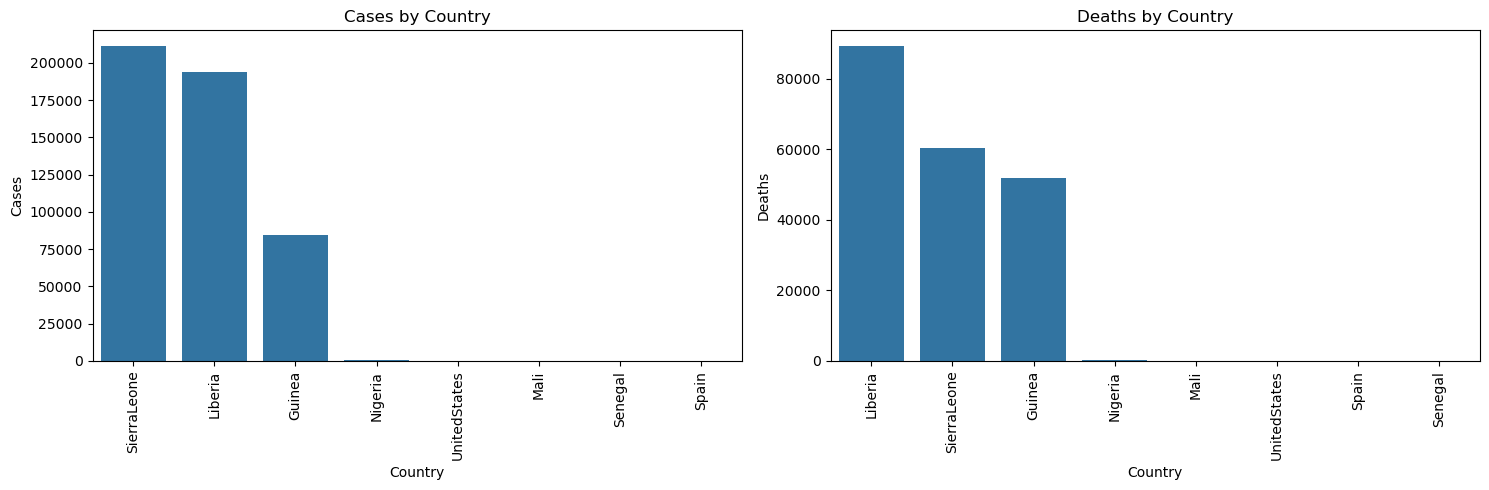

In [370]:
fig,axis=plt.subplots(1,2,figsize=(15,5))
order_by_cases = df1.groupby(['Country'])['Cases'].sum().reset_index().sort_values(by='Cases',ascending=False)['Country'].tolist()
order_by_deaths = df1.groupby(['Country'])['Deaths'].sum().reset_index().sort_values(by='Deaths',ascending=False)['Country'].tolist()
sns.barplot(x=df1.groupby(['Country'])['Cases'].sum().reset_index()['Country'],y=df1.groupby(['Country'])['Cases'].sum().reset_index()['Cases'],order=order_by_cases,ax=axis[0])

sns.barplot(x=df1.groupby(['Country'])['Deaths'].sum().reset_index()['Country'],y=df1.groupby(['Country'])['Deaths'].sum().reset_index()['Deaths'],order=order_by_deaths,ax=axis[1])

axis[0].tick_params(axis='x',rotation = 90)
axis[1].tick_params(axis='x',rotation = 90)
axis[0].set_title('Cases by Country')
axis[1].set_title('Deaths by Country')
plt.tight_layout();

### The bar charts display the total number of cases and deaths by country. Sierra Leone reports the highest total number of cases, reflecting the largest outbreak in terms of infections. In contrast, Liberia records the highest total number of deaths, indicating that, despite having fewer cases than Sierra Leone, the outbreak in Liberia was proportionally more severe in terms of fatalities. This comparison highlights differences in outbreak impact between countries, possibly due to variations in healthcare response, case management, or reporting practices.

# Which Country has the highest death rate?

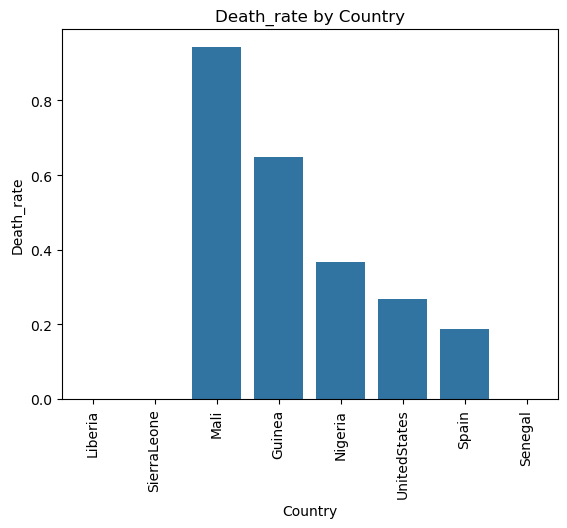

In [377]:
order_by_rate=df1.groupby('Country')['Death_rate'].mean().reset_index().sort_values(by='Death_rate',ascending=False)['Country'].tolist()


sns.barplot(x=df1.groupby('Country')['Death_rate'].mean().reset_index()['Country'],y=df1.groupby('Country')['Death_rate'].mean().reset_index()['Death_rate'],order=order_by_rate)
plt.xticks(rotation=90)
plt.title('Death_rate by Country');

### The bar chart depicting death rate by country highlights that Mali experienced the highest proportion of deaths per reported cases, followed by Guinea and Nigeria. This suggests that, although these countries may not have had the largest total number of cases, the outbreak was relatively more severe for infected individuals. Interestingly, the chart also shows the United States and Spain, which likely reflects cases among healthcare workers or operators who were exposed while working in affected regions, rather than widespread community transmission.

# Reflective Conclusion

This project has provided a valuable and stimulating challenge, allowing me to strengthen both Python programming skills and data interpretation abilities. Handling the Ebola dataset required not only cleaning and transforming the data into a usable format, but also thoughtfully addressing issues such as missing values, unbalanced observations across years, and anomalous ratios like infinite death rates.

Developing visualizations ranging from bar plots and line charts to cumulative curves—reinforced the importance of clear and accurate data presentation, while simultaneously deepening understanding of epidemiological trends and patterns across countries and weeks. The process of analyzing cumulative trends, death rates, and country-level differences required combining coding proficiency with statistical reasoning and critical interpretation.

Overall, the assignment has been highly instructive, offering hands-on experience in data preprocessing, aggregation, visualization, and analytical reasoning. It highlighted the interplay between programming skills and domain-specific knowledge, demonstrating how careful data manipulation and thoughtful visualization can lead to meaningful insights and robust conclusions. The challenges encountered have ultimately strengthened confidence in approaching real-world datasets and deriving actionable understanding from complex information.